# Fuzzy RDD


**🌐 언어:** [← English](/fuzzy-rdd-en) | **한국어**

<small><em>작성자 손지우 · <a href="https://github.com/bungaedm">GitHub</a> · <a href="https://www.linkedin.com/in/jiwoo-son-3207021a7/">LinkedIn</a></em></small>


In [1]:
from IPython.display import HTML
HTML('''<iframe width="560" height="315" src="https://www.youtube.com/embed/PPYkTG79ff0" title="YouTube video player" frameborder="0" allow="accelerometer; autoplay; clipboard-write; encrypted-media; gyroscope; picture-in-picture; web-share" referrerpolicy="strict-origin-when-cross-origin" allowfullscreen></iframe>''')

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import warnings

plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

np.random.seed(2026)
warnings.filterwarnings('ignore')

## Recap. Sharp vs Fuzzy RDD

[이전 챕터](/rdd-basic-ko)에서 RDD의 기본을 배웠습니다. 막간에 복습을 해보자면, RDD는 크게 Sharp RDD와 Fuzzy RDD의 두 종류가 있고, 이전 챕터에서는 Sharp RDD를 기준으로 말씀드렸습니다. Sharp RDD에서는 아래의 수식에서 확인할 수 있듯이, 임계점 $c$는 처치를 **완전히** 결정합니다.

$$D_i^{\text{Sharp}} = \mathbf{1}[X_i \geq c]$$

예를 들면, 수능 370점 이상이면 반드시 장학금을 받고, 미만이면 절대 못 받으면 이는 Sharp RDD 구조입니다.

하지만 현실에서는 이런 "완벽한 규칙"이 드뭅니다. 370점을 넘어도 장학금 신청을 하지 않거나, 서류 미비로 탈락할 수 있고, 반대로 369점이어도 입학 전형에 따라 재심사를 통해 받는 경우가 특수 케이스가 있습니다. 이처럼 임계점이 처치 확률에 **불연속적인 영향**을 주지만 완전히 결정하지는 않는 경우를 **Fuzzy RDD**라고 합니다.

$$0 \;<\; \lim_{x \rightarrow c+} \Pr(D_i^{\text{Fuzzy}} = 1 \mid X_i = x) \;-\; \lim_{x \rightarrow c-} \Pr(D_i^{\text{Fuzzy}} = 1 \mid X_i = x) \;<\; 1$$

즉, 임계점에서 처치 확률이 불연속적으로 상승하지만, 그 점프가 0→1의 완전한 점프는 아닙니다.

| 구분 | 임계점에서 변화 | 추정 방법 |
|------|--------------|---------|
| **Sharp RDD** | 처치 확률 0% → 100% | OLS (불연속 회귀) |
| **Fuzzy RDD** | 처치 확률 일부 점프 (예: 15% → 65%) | 2SLS (IV) |

In [2]:
def plot_rdd_type():
    c = 0
    R = np.linspace(-3, 3, 300)
    
    D_sharp = np.where(R >= c, 1.0, 0.0)
    
    D_fuzzy = np.where(R >= c,
                       0.65 + 0.1 * np.tanh(R * 2),
                       0.15 + 0.1 * np.tanh(R * 2))
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # ── Sharp RDD ──
    ax = axes[0]
    ax.plot(R[R <  c], D_sharp[R <  c], 'tomato',    linewidth=3, label=r'$P(D=1|R)$: $R < c$')
    ax.plot(R[R >= c], D_sharp[R >= c], 'steelblue', linewidth=3, label=r'$P(D=1|R)$: $R \geq c$')
    ax.axvline(c, color='gray', linestyle=':', linewidth=1.5)
    ax.scatter([c], [0], s=80, color='tomato', zorder=5, edgecolors='tomato', facecolors='none', linewidths=2)
    ax.scatter([c], [1], s=80, zorder=5)
    ax.annotate('', xy=(c, 1.0), xytext=(c, 0.0),
                arrowprops=dict(arrowstyle='<->', color='black', lw=2))
    ax.text(c + 0.1, 0.5, '0 → 1\n(perfect jump)', fontsize=11, va='center', fontweight='bold')
    ax.text(c + 0.05, -0.07, '$c$', fontsize=12, color='gray')
    ax.set_ylim(-0.15, 1.25)
    ax.set_title('Sharp RDD', fontsize=13, fontweight='bold')
    ax.set_xlabel('Running Variable $R$', fontsize=11)
    ax.set_ylabel(r'$P(D=1 \mid R)$', fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    
    # ── Fuzzy RDD ──
    ax = axes[1]
    ax.plot(R[R <  c], D_fuzzy[R <  c], 'tomato',    linewidth=3, label=r'$P(D=1|R)$: $R < c$')
    ax.plot(R[R >= c], D_fuzzy[R >= c], 'steelblue', linewidth=3, label=r'$P(D=1|R)$: $R \geq c$')
    ax.axvline(c, color='gray', linestyle=':', linewidth=1.5)
    
    d_l = np.interp(c - 0.009, R, D_fuzzy)
    d_r = np.interp(c + 0.009, R, D_fuzzy)
    ax.scatter([c], [d_l], s=80, color='tomato', zorder=5, facecolors='none', edgecolors='tomato', linewidths=2)
    ax.scatter([c], [d_r], s=80, zorder=5)
    ax.annotate('', xy=(c, d_r), xytext=(c, d_l),
                arrowprops=dict(arrowstyle='<->', color='black', lw=2))
    ax.text(c + 0.1, (d_l + d_r) / 2,
            f'{d_l:.2f} → {d_r:.2f}\n(partial jump)', fontsize=11, va='center', fontweight='bold')
    ax.text(c + 0.05, -0.07, '$c$', fontsize=12, color='gray')
    ax.set_ylim(-0.15, 1.25)
    ax.set_title('Fuzzy RDD', fontsize=13, fontweight='bold')
    ax.set_xlabel('Running Variable $R$', fontsize=11)
    ax.set_ylabel(r'$P(D=1 \mid R)$', fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    
    fig.suptitle(r'Sharp vs Fuzzy RDD — $P(D=1 \mid R)$', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

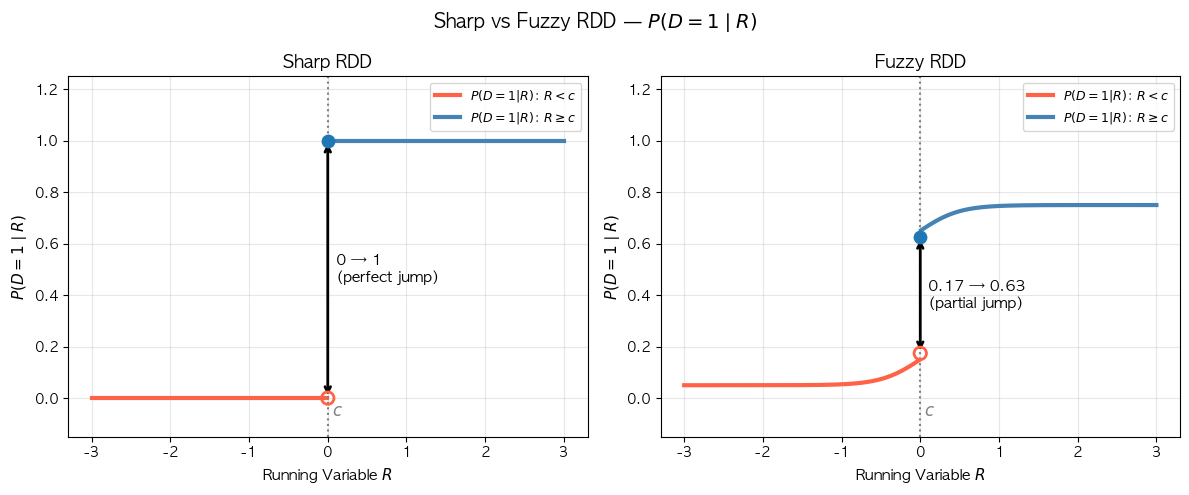

In [3]:
plot_rdd_type()

## 1. Fuzzy RDD란?

한 줄로 요약하자면, Fuzzy RDD는 컷오프 기준이 처치를 "100% 강제"하지 않을 때의 RDD입니다.

예를 들자면, 일반 입학전형의 경우, 수능 370점을 기준으로 장학금 **신청 자격**이 생긴다고 합시다. Sharp RDD라면 자격이 생기는 순간 모두가 장학금을 받을 것입니다. 하지만 현실은 이렇습니다.

- 371점을 받아 자격은 생겼지만 신청 기간을 놓친 학생
- 372점이어도 제출 서류가 미비해서 탈락한 학생
- 375점이어도 부유한 가정이라 신청하지 않은 학생

반대로 368점이어도 재심사나 특별 전형으로 장학금을 받게 되는 경우도 있습니다.

임계점은 자격 여부에 영향을 주지만, 실제 처치는 그 자격에 반드시 따르지 않습니다. 이러한 경우는 Fuzzy RDD의 구조를 따른다고 할 수 있습니다.

이를 이해하기 위해, 아래의 핵심 변수들의 정의를 명확히 해보겠습니다.

- $X_i$: Running Variable (수능 점수)
- $Z_i$: 도구변수 (장학금 자격 부여 여부 = 수능 370점 이상 여부)
- $D_i$: 처치변수 (실제 장학금 수혜 여부)
- $Y_i$: 결과변수 (GPA)

참고로, Sharp RDD에서는 $Z_i = D_i$였습니다. 하지만 Fuzzy RDD에서는 $Z_i \neq D_i$이고, 이는 $Z_i$가 $D_i$에 영향을 주지만 완전히 결정하지는 않는다는 것을 의미합니다.

## 2. 어떻게 효과를 추정하는가

Sharp RDD에서는 효과 추정이 단순했습니다. 임계점 바로 왼쪽과 오른쪽은 거의 같은 학생들인데 한쪽은 100% 처치를 받고 다른 쪽은 0%를 받으니, 임계점에서 결과($Y$)가 **점프한 크기 자체가 곧 처치 효과**였습니다.

그런데 Fuzzy RDD에서는 한 가지 문제가 생깁니다. 임계점을 넘어도 **일부만** 처치를 받습니다. 숫자로 보겠습니다. 수능 370점을 기준으로:

- 자격이 없을 때(369점 이하): 10%만 장학금을 받음
- 자격이 생겼을 때(370점 이상): 65%가 장학금을 받음

즉 임계점을 넘었다고 모두가 처치를 받는 게 아니라, 처치율이 10% → 65%로 55%p만 점프합니다. 이때 GPA가 임계점에서 0.5점 점프했다면, 이 0.5점은 모두가 아니라 "55%p의 추가 수혜자"가 만들어낸 효과입니다.

그렇다면 처치를 **실제로** 받게 된 사람 1명당 효과는 얼마일까요? 점프한 결과를 점프한 처치율로 나눠주면 됩니다.

$$\hat{\tau}_{Fuzzy} = \frac{\text{Y의 점프}}{\text{D의 점프}} = \frac{0.5}{0.55} \approx 0.91$$

이러한 형태를 **Wald 추정량**이라고 하며, 이처럼 결과가 점프한 양을 처치가 점프한 양으로 나누어서 처치 1단위당 효과를 복원하는 것이 Wald 추정량의 핵심 직관입니다. 분자와 분모에 이름을 붙이면 다음과 같습니다.

- **분자 ($\widehat{\text{ITT}}_Y$)**: 자격($Z$)이 결과($Y$)에 일으킨 점프 — "자격을 줬더니 GPA가 얼마나 올랐나"
- **분모 ($\widehat{\text{ITT}}_D$)**: 자격($Z$)이 처치($D$)에 일으킨 점프 — "자격을 줬더니 실제 수혜율이 얼마나 올랐나"

$$\hat{\tau}_{Fuzzy} = \frac{\widehat{\text{ITT}}_Y}{\widehat{\text{ITT}}_D}$$

> ITT는 Intention-To-Treat(처치 의도)의 약자로, "실제 처치 여부"가 아니라 "처치 자격을 부여한 것"의 효과를 뜻합니다.

이렇게 보면 Sharp RDD는 Fuzzy RDD의 특수한 경우입니다. 처치율이 0% → 100%로 완전히 점프하면 분모($\widehat{\text{ITT}}_D$)가 1이 되어, $Y$의 점프가 그대로 효과가 됩니다.

## 3. 추정된 효과는 무엇을 의미하는가

방금 우리는 "처치를 실제로 받게 된 사람 1명당 효과"를 구했습니다. 그런데 여기서 자연스러운 질문이 하나 남습니다. 그 "처치를 받게 된 사람"은 정확히 누구일까요?

핵심은 이것입니다. 임계점 근처에서 자격($Z$)이 생기든 말든 어차피 장학금을 받았을 사람(국가유공자 등)이나, 자격이 생겨도 어차피 안 받았을 사람(외국인 등)은 Wald 추정량에 잡히지 않습니다. 분자와 분모 모두 "자격 때문에 **행동이 바뀐** 사람"만 반영하기 때문입니다.

이렇게 자격이 생겼기 때문에 비로소 처치를 받게 된 사람을 공식 용어로는 **순응자**(Complier)라고 부릅니다. Fuzzy RDD가 추정하는 효과는 바로 이 순응자들에 대한 효과이며, 조금 더 정확하게는 이들의 기준점 근방에서의 처치 효과인 **LATE**(Local Average Treatment Effect, 국소 평균 처치 효과)입니다.

자격 여부($Z$)에 따라 사람을 네 유형으로 나눠보면, 순응자가 어떤 사람인지 분명해집니다.

In [4]:
pd.DataFrame({
    '유형': ['순응자 (Complier)', '항상 수혜자 (Always-taker)', '절대 비수혜자 (Never-taker)', '위반자 (Defier)'],
    'Z=0일 때 D': [0, 1, 0, 1],
    'Z=1일 때 D': [1, 1, 0, 0],
    '설명': [
        '자격이 생겼을 때만 처치를 받는다 ← 추정 대상',
        '자격과 무관하게 항상 처치를 받는다',
        '자격이 생겨도 처치를 받지 않는다',
        '자격이 생기면 오히려 처치를 거부한다 (단조성 가정으로 배제)',
    ]
})

,유형,Z=0일 때 D,Z=1일 때 D,설명
0,순응자 (Complier),0,1,자격이 생겼을 때만 처치를 받는다 ← 추정 대상
1,항상 수혜자 (Always-taker),1,1,자격과 무관하게 항상 처치를 받는다
2,절대 비수혜자 (Never-taker),0,0,자격이 생겨도 처치를 받지 않는다
3,위반자 (Defier),1,0,자격이 생기면 오히려 처치를 거부한다 (단조성 가정으로 배제)


위반자(Defier), 즉 "자격이 생기면 오히려 처치를 거부하는 사람"은 없다고 가정합니다(단조성 가정, 자세히는 다음 절에서). 그러면 임계점 근방에서 추정되는 효과는 다음과 같이 깔끔하게 정리됩니다.

$$\tau^{Fuzzy} = \mathbb{E}[Y_i(1) - Y_i(0) \mid \text{Complier},\; X_i = c]$$

말로 풀면, 자격이 생겼기 때문에 처치를 받게 된 사람들(순응자)의, 임계점 근방에서의 처치 효과입니다. 이 효과에서는 항상 수혜자(Always-taker)나 절대 비수혜자(Never-taker)는 포함되지 않습니다. 자격과 무관하게 늘 받거나 늘 안 받는 사람들의 효과는 알 수 없기 때문입니다. 이것이 Fuzzy RDD의 근본적인 한계이자, 동시에 모르는 것을 모른다고 말하는 정직한 추정입니다. 추정된 효과는 누구의 것인가-라는 질문에 대해 이제 우리는 "순응자(Complier)의 LATE"라고 답할 수 있게 되었습니다.

```{quiz} fuzzy-rdd-complier
:single:
:bank: rdd/quizzes.json
:lang: ko
```

## 4. 핵심 가정

지금까지 우리는 자격 여부($Z$)를 지렛대로 삼아 효과를 구했습니다. 사실 이 자격 $Z_i = \mathbf{1}[X_i \geq c]$가 바로 **도구변수**(Instrumental Variable, IV)입니다. 즉, Fuzzy RDD는 본질적으로 도구변수 추정 문제인 셈입니다. 도구변수가 유효해야 앞서 본 Wald 추정량을 신뢰할 수 있고, 그러기 위해서는 세 가지 조건이 필요합니다. (도구변수에 대해서 잘 알고 계신 분이라면 해당 절은 스킵하셔도 좋습니다.)

### 관련성 (Relevance)

$Z_i$는 $D_i$에 실질적으로 영향을 주어야 합니다. 즉 자격이 생기면 처치 확률이 실제로 올라가야 합니다. 이는 Wald 추정량의 **분모($\widehat{\text{ITT}}_D$)가 0이 아니어야** 한다는 말과 같습니다(분모가 0이면 나눗셈 자체가 무너집니다).

$$\text{Cov}(Z_i,\, D_i) \neq 0$$

1단계 회귀의 F-통계량으로 확인하며, 통상 $F > 10$이면 강한 도구변수로 판단합니다.

### 배제 제약 (Exclusion Restriction)

$Z_i$는 오직 $D_i$를 통해서만 $Y_i$에 영향을 주어야 합니다. 예를 들어, 약을 처방받았다는 사실 자체가 (약을 먹기도 전에) 건강 상태를 직접 바꾸지는 않아야 합니다. 약을 먹었기 때문에 건강 상태가 좋아지는 것이지, 약을 처방받았다는 것만으로 건강상태가 바뀐다면 그건 배제 제약이 위반된 케이스라고 볼 수 있습니다.

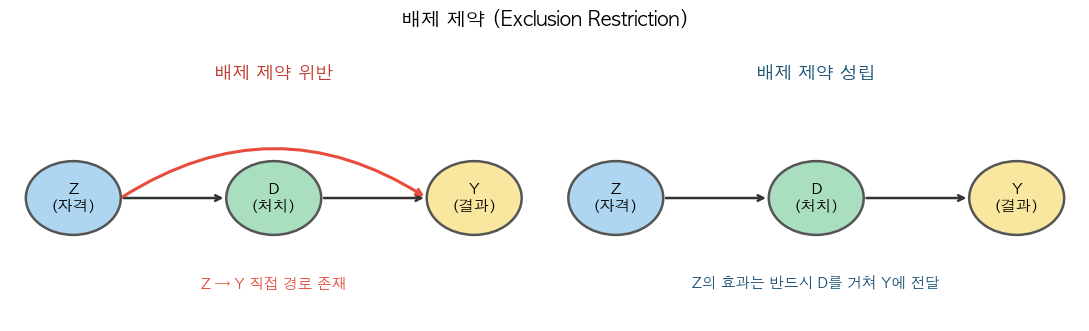

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.2))

pos = {'Z': (0.12, 0.55), 'D': (0.50, 0.55), 'Y': (0.88, 0.55)}
node_colors = {'Z': '#AED6F1', 'D': '#A9DFBF', 'Y': '#F9E79F'}
node_labels = {'Z': 'Z\n(자격)', 'D': 'D\n(처치)', 'Y': 'Y\n(결과)'}
R = 0.09

def draw_nodes(ax):
    for name, (x, y) in pos.items():
        circle = plt.Circle((x, y), R, color=node_colors[name], ec='#555', lw=1.8, zorder=3)
        ax.add_patch(circle)
        ax.text(x, y, node_labels[name], ha='center', va='center', fontsize=11,
                fontweight='bold', zorder=4, linespacing=1.3)

def arrow(ax, a, b, color='#333', lw=1.8, rad=0.0):
    x1, y1 = pos[a]; x2, y2 = pos[b]
    dx, dy = x2 - x1, y2 - y1
    dist = (dx**2 + dy**2) ** 0.5
    sx = x1 + R * dx / dist;  sy = y1 + R * dy / dist
    ex = x2 - R * dx / dist;  ey = y2 - R * dy / dist
    ax.annotate('', xy=(ex, ey), xytext=(sx, sy),
                arrowprops=dict(arrowstyle='->', color=color, lw=lw,
                                connectionstyle=f'arc3,rad={rad}'))

mx = (pos['Z'][0] + pos['Y'][0]) / 2

# ── 왼쪽: 배제 제약 위반 ──
ax = axes[0]
ax.set_xlim(0, 1); ax.set_ylim(0.25, 0.82); ax.axis('off')
ax.set_title('배제 제약 위반', fontsize=13, fontweight='bold', color='#C0392B', pad=6)
draw_nodes(ax)
arrow(ax, 'Z', 'D')
arrow(ax, 'D', 'Y')
arrow(ax, 'Z', 'Y', color='#E74C3C', lw=2.2, rad=-0.32)
ax.text(mx, 0.33, 'Z → Y 직접 경로 존재',
        color='#E74C3C', fontsize=10.5, ha='center', fontweight='bold')

# ── 오른쪽: 배제 제약 성립 ──
ax2 = axes[1]
ax2.set_xlim(0, 1); ax2.set_ylim(0.25, 0.82); ax2.axis('off')
ax2.set_title('배제 제약 성립', fontsize=13, fontweight='bold', color='#1A5276', pad=6)
draw_nodes(ax2)
arrow(ax2, 'Z', 'D')
arrow(ax2, 'D', 'Y')
ax2.text(mx, 0.33, 'Z의 효과는 반드시 D를 거쳐 Y에 전달',
         color='#1A5276', fontsize=10.5, ha='center', fontweight='bold')

plt.suptitle('배제 제약 (Exclusion Restriction)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


### 단조성 (Monotonicity)

위반자(Defier)가 없어야 합니다. 즉 자격이 생겼을 때 처치를 **오히려 거부하는** 사람이 없어야 합니다. 이 가정이 있어야 임계점에서 늘어난 처치가 전부 "순응자가 추가로 받은 것"으로 깔끔하게 해석됩니다(3절의 순응자 정의와 직접 연결됩니다).

$$D_i(Z=1) \geq D_i(Z=0) \quad \forall i$$

---

이 세 가지 가정(관련성·배제 제약·단조성)이 성립하면, 2절에서 본 Wald 추정량 $\widehat{\text{ITT}}_Y / \widehat{\text{ITT}}_D$가 순응자에 대한 인과효과(LATE)로 해석됩니다. 다음 절에서는 이 Wald 추정량을 회귀로 실제로 추정하는 방법인 **2SLS**를 살펴봅니다.

## 5. 2SLS로 추정하기

2절에서 Wald 추정량 $\widehat{\text{ITT}}_Y / \widehat{\text{ITT}}_D$로 LATE의 직관을 잡았습니다. 실제 분석에서는 이를 손으로 나누는 대신 **2SLS**(2단계 최소제곱법, Two-Stage Least Squares)이라는 방법론으로 추정합니다. 해당 방법론을 활용하여 산출한 점 추정치는 Wald와 정확히 같으며, **표준오차(신뢰구간)까지 제대로 얻을 수 있다**는 장점이 있습니다.

다만 2SLS로 추정하기 전에, Reduced Form을 통해 사전점검을 할 필요가 있습니다. 이를 정리하면 아래의 세 가지로 구분할 수 있습니다. 다소 복잡해보이지만, 결국 2절에서 이야기한 분자·분모를 회귀로 구하는 것뿐입니다.

| 이름 | 경로 | 추정 대상 | 역할 |
|------|------|-----------|------|
| **Reduced Form** | $Z_i \rightarrow Y_i$ | $\widehat{\text{ITT}}_Y$ (Wald 분자) | 사전 점검 |
| **2SLS 1단계 (First Stage)** | $Z_i \rightarrow D_i$ | $\widehat{\text{ITT}}_D$ (Wald 분모) | 도구변수 강도 확인 |
| **2SLS 2단계 (Second Stage)** | $\hat{D}_i \rightarrow Y_i$ | $\text{LATE}$ | 최종 추정 |

---

### Reduced Form: $Z_i \rightarrow Y_i$ (= Wald 분자)

$$Y_i = \gamma_0 + \gamma_1 Z_i + \gamma_2(X_i - c) + \gamma_3 Z_i(X_i - c) + \varepsilon_i$$

- **핵심 계수**: $\hat{\gamma}_1 = \widehat{\text{ITT}}_Y$ (임계점에서 Y가 점프한 크기)
- **두 가지 역할**
    - **사전 점검**: 2SLS를 돌리기 전에 "자격 $Z_i$가 결과 $Y_i$에 실제로 닿는가"를 확인합니다. $\hat{\gamma}_1 \approx 0$이면 효과 자체가 없다는 신호이므로 분석 설계를 재검토해야 합니다.
    - **Wald 분자**: 동시에 $\hat{\gamma}_1$은 Wald 추정량의 분자로 그대로 쓰입니다.

---

### 2SLS: 왜 두 단계로 나누는가

$D_i$(실제 처치)는 **내생변수**입니다. 장학금을 받은 사람과 받지 않은 사람은 처음부터 다를 수 있어(능력, 동기 등), $Y_i$를 $D_i$에 곧바로 회귀하면 편향이 생깁니다. 2SLS는 $D_i$ 중에서 **도구변수 $Z_i$ 때문에 외생적으로 생긴 부분만** 뽑아내어, 그 부분으로 $Y_i$를 설명합니다.

#### 1단계 (First Stage): $Z_i \rightarrow D_i$ (= Wald 분모)

$$D_i = \alpha_0 + \alpha_1 Z_i + \alpha_2(X_i - c) + \alpha_3 Z_i(X_i - c) + \varepsilon_i^{(1)}$$

- **핵심 계수**: $\hat{\alpha}_1 = \widehat{\text{ITT}}_D$ (임계점에서 처치 확률이 점프한 크기)
- **진단**: F-통계량 $\geq 10$이면 강한 도구변수, 미만이면 약한 도구변수(weak instrument) 문제.
- **출력물**: 예측치 $\hat{D}_i$ — 도구변수로 설명되는 "처치의 외생적인 부분"

#### 2단계 (Second Stage): $\hat{D}_i \rightarrow Y_i$

$$Y_i = \beta_0 + \beta_1 \hat{D}_i + \beta_2(X_i - c) + \beta_3 \hat{D}_i(X_i - c) + \varepsilon_i^{(2)}$$

- 1단계 예측치 $\hat{D}_i$를 처치변수 자리에 넣어, 내생성이 제거된 처치 효과를 추정합니다.
- **핵심 계수**: $\hat{\beta}_1$ = **LATE 추정량**

---

### 결국 둘은 같다

2SLS 2단계의 $\hat{\beta}_1$은 2절에서 손으로 구한 Wald 추정량과 정확히 일치합니다.

$$\hat{\beta}_1 = \frac{\hat{\gamma}_1}{\hat{\alpha}_1} = \frac{\widehat{\text{ITT}}_Y}{\widehat{\text{ITT}}_D}$$

다시 한번 수능 예시로 확인하면, 자격이 생겼을 때 GPA가 0.5점 오르고($\text{ITT}_Y$) 처치 확률이 55%p만큼 오른다면($\text{ITT}_D$), 순응자 1명당 효과는 $0.5 \div 0.55 \approx 0.91$점입니다. 2절에서 직관으로 구한 값과 같습니다.

> **주의**: 위처럼 2단계를 수동으로 구현하면 점 추정치($\hat{\beta}_1$)는 맞지만 **표준오차가 과소 추정**됩니다. 실제 분석에서는 `linearmodels` 같은 IV 추정 패키지를 사용해 표준오차를 정확히 얻어야 합니다.

## 6. 시각화

Fuzzy RDD 추정의 세 단계를 한 화면에서 확인합니다. 그래프를 보기 전에 각 패널이 무엇을 담고 있는지 파악해두세요.

- **왼쪽 — Reduced Form (Z → Y)**: 수능 점수(X)와 GPA(Y)의 산점도입니다. 기준점 좌우에 각각 회귀선을 적합하고, 임계점에서 GPA가 얼마나 뛰는지($\widehat{\text{ITT}}_Y$ = Wald 분자)를 보여줍니다. 2SLS를 실행하기 전, 도구변수가 결과에 실제로 닿는지 확인하는 사전점검 역할을 합니다.
- **가운데 — 2SLS 1단계 (Z → D)**: 수능 점수(X)와 실제 처치 여부(D)의 산점도입니다. 임계점에서 처치 확률이 얼마나 뛰는지($\widehat{\text{ITT}}_D$ = Wald 분모)를 보여줍니다. 도구변수의 강도를 시각적으로 확인합니다.
- **오른쪽 — 2SLS 2단계 결과**: 2SLS로 추정한 LATE와 95% 신뢰구간입니다. 다이아몬드(◆)가 점 추정값, 가로 선이 신뢰구간, 초록 점선이 시뮬레이션에서 설정한 True LATE입니다.

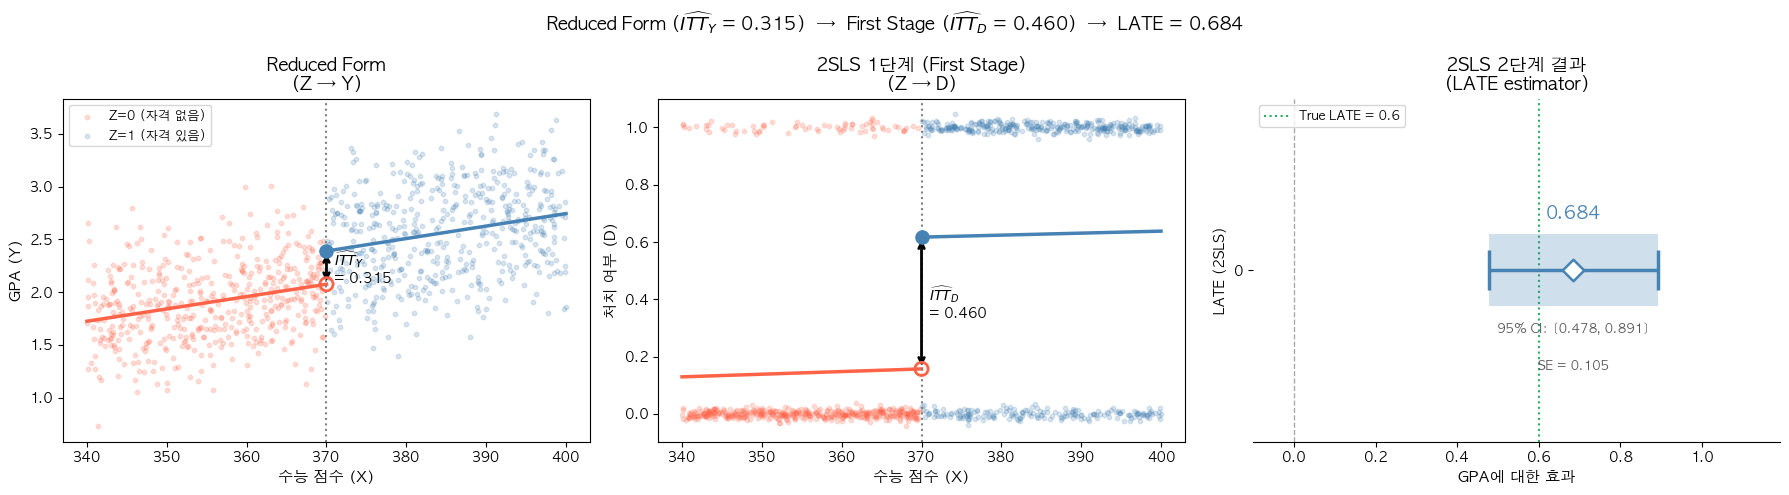

In [6]:
n = 1000
cutoff = 370
true_late = 0.6

score   = np.random.uniform(340, 400, n)
elig    = (score >= cutoff).astype(int)
treated = np.where(elig == 1,
                   np.random.binomial(1, 0.65, n),
                   np.random.binomial(1, 0.15, n))
gpa = (2.0 + 0.012*(score - cutoff)
       + true_late * treated
       + np.random.normal(0, 0.3, n))

df_viz = pd.DataFrame({'score': score, 'elig': elig,
                       'treated': treated, 'gpa': gpa,
                       'score_c': score - cutoff})

# First stage → D_hat
fs_viz = smf.ols('treated ~ elig + score_c + elig:score_c', data=df_viz).fit()
df_viz['D_hat'] = fs_viz.fittedvalues

# Second stage → LATE
ss_viz  = smf.ols('gpa ~ D_hat + score_c + D_hat:score_c', data=df_viz).fit()
LATE    = ss_viz.params['D_hat']
LATE_se = ss_viz.bse['D_hat']
LATE_ci = ss_viz.conf_int().loc['D_hat'].values   # [lower, upper]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
left  = df_viz[df_viz['elig'] == 0]
right = df_viz[df_viz['elig'] == 1]
xs_l  = np.linspace(340, cutoff, 100)
xs_r  = np.linspace(cutoff, 400, 100)

ACCENT = 'steelblue'
GREEN  = '#27ae60'
GRAY   = '#555555'

# ── 왼쪽: Reduced Form (Z → Y) ──
ax = axes[0]
ax.scatter(left['score'],  left['gpa'],  color='tomato',    alpha=0.2, s=10, label='Z=0 (자격 없음)')
ax.scatter(right['score'], right['gpa'], color='steelblue', alpha=0.2, s=10, label='Z=1 (자격 있음)')
m_y_l = smf.ols('gpa ~ score_c', data=left).fit()
m_y_r = smf.ols('gpa ~ score_c', data=right).fit()
ax.plot(xs_l, m_y_l.predict(pd.DataFrame({'score_c': xs_l - cutoff})), color='tomato',    lw=2.5)
ax.plot(xs_r, m_y_r.predict(pd.DataFrame({'score_c': xs_r - cutoff})), color='steelblue', lw=2.5)
y_l_gpa = m_y_l.params['Intercept']
y_r_gpa = m_y_r.params['Intercept']
ax.scatter([cutoff], [y_l_gpa], s=90, color='tomato',    zorder=6, facecolors='none', edgecolors='tomato', linewidths=2)
ax.scatter([cutoff], [y_r_gpa], s=90, color='steelblue', zorder=6)
ax.annotate('', xy=(cutoff, y_r_gpa), xytext=(cutoff, y_l_gpa),
            arrowprops=dict(arrowstyle='<->', color='black', lw=2))
ax.text(cutoff + 1, (y_l_gpa + y_r_gpa) / 2,
        f'$\\widehat{{ITT}}_Y$\n= {y_r_gpa - y_l_gpa:.3f}', fontsize=10, fontweight='bold', va='center')
ax.axvline(cutoff, color='gray', ls=':', lw=1.5)
ax.set_title('Reduced Form\n(Z → Y)', fontsize=13, fontweight='bold')
ax.set_xlabel('수능 점수 (X)', fontsize=11)
ax.set_ylabel('GPA (Y)', fontsize=11)
ax.legend(fontsize=9)

# ── 가운데: 2SLS 1단계 (Z → D) ──
ax2 = axes[1]
ax2.scatter(left['score'],  left['treated']  + np.random.normal(0, 0.012, len(left)),
            color='tomato',    alpha=0.2, s=10)
ax2.scatter(right['score'], right['treated'] + np.random.normal(0, 0.012, len(right)),
            color='steelblue', alpha=0.2, s=10)
m_d_l = smf.ols('treated ~ score_c', data=left).fit()
m_d_r = smf.ols('treated ~ score_c', data=right).fit()
ax2.plot(xs_l, m_d_l.predict(pd.DataFrame({'score_c': xs_l - cutoff})), color='tomato',    lw=2.5)
ax2.plot(xs_r, m_d_r.predict(pd.DataFrame({'score_c': xs_r - cutoff})), color='steelblue', lw=2.5)
y_l_d = m_d_l.params['Intercept']
y_r_d = m_d_r.params['Intercept']
ax2.scatter([cutoff], [y_l_d], s=90, color='tomato',    zorder=6, facecolors='none', edgecolors='tomato', linewidths=2)
ax2.scatter([cutoff], [y_r_d], s=90, color='steelblue', zorder=6)
ax2.annotate('', xy=(cutoff, y_r_d), xytext=(cutoff, y_l_d),
             arrowprops=dict(arrowstyle='<->', color='black', lw=2))
ax2.text(cutoff + 1, (y_l_d + y_r_d) / 2,
         f'$\\widehat{{ITT}}_D$\n= {y_r_d - y_l_d:.3f}', fontsize=10, fontweight='bold', va='center')
ax2.axvline(cutoff, color='gray', ls=':', lw=1.5)
ax2.set_title('2SLS 1단계 (First Stage)\n(Z → D)', fontsize=13, fontweight='bold')
ax2.set_xlabel('수능 점수 (X)', fontsize=11)
ax2.set_ylabel('처치 여부 (D)', fontsize=11)

# ── 오른쪽: Forest Plot (LATE + 95% CI) ──
ax3 = axes[2]
y_pos = 0
ax3.barh(y_pos, LATE_ci[1] - LATE_ci[0], left=LATE_ci[0],
         height=0.25, color=ACCENT, alpha=0.25, zorder=2) # CI 구간 음영
ax3.hlines(y_pos, LATE_ci[0], LATE_ci[1],
           colors=ACCENT, lw=2.5, zorder=3) # CI 수평선
ax3.vlines([LATE_ci[0], LATE_ci[1]], y_pos - 0.07, y_pos + 0.07,
           colors=ACCENT, lw=2.5, zorder=3) # 끝 캡
ax3.scatter([LATE], [y_pos], color='white', s=120,
            marker='D', zorder=5, edgecolors=ACCENT, linewidths=1.8) # 점 추정값 (다이아몬드)
ax3.axvline(true_late, color=GREEN, lw=1.5, ls=':',
            label=f'True LATE = {true_late}', zorder=1) # True effect 수직선
ax3.axvline(0, color=GRAY, lw=1, ls='--', alpha=0.5, zorder=1) # 영(0) 기준선
ax3.text(LATE, y_pos + 0.18, f'{LATE:.3f}',
         ha='center', color=ACCENT, fontsize=13, fontweight='bold')
ax3.text(LATE, y_pos - 0.22,
         f'95% CI: [{LATE_ci[0]:.3f}, {LATE_ci[1]:.3f}]',
         ha='center', color=GRAY, fontsize=9)
ax3.text(LATE, y_pos - 0.35, f'SE = {LATE_se:.3f}',
         ha='center', color=GRAY, fontsize=9)

ax3.set_xlim(min(LATE_ci[0] - 0.3, -0.1), max(LATE_ci[1] + 0.3, true_late + 0.2))
ax3.set_ylim(-0.6, 0.6)
ax3.set_yticks([0])
ax3.set_title('2SLS 2단계 결과\n(LATE estimator)', fontsize=13, fontweight='bold')
ax3.set_xlabel('GPA에 대한 효과', fontsize=11)
ax3.set_ylabel('LATE (2SLS)', fontsize=10)
ax3.legend(fontsize=9, loc='upper left')
ax3.spines[['top', 'right', 'left']].set_visible(False)

plt.suptitle(
    f'Reduced Form ($\\widehat{{ITT}}_Y$ = {y_r_gpa - y_l_gpa:.3f})  →  '
    f'First Stage ($\\widehat{{ITT}}_D$ = {y_r_d - y_l_d:.3f})  →  '
    f'LATE = {LATE:.3f}',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()

그래프를 보며 확인해야 할 포인트들입니다.

**왼쪽과 가운데: 두 점프가 같은 방향으로 뚜렷이 나타나는지 확인하세요.** Reduced Form에서 자격($Z$)이 결과($Y$)에 닿아 $\widehat{\text{ITT}}_Y$가 0에서 충분히 벗어나야 하고, First Stage에서도 처치($D$)가 같은 방향으로 점프해 $\widehat{\text{ITT}}_D$가 0이 아니어야 합니다. 만약 Y 점프가 거의 0이라면 자격이 결과에 영향을 주지 못한다는 신호이므로 설계를 재검토해야 합니다.

> **주의 — Y 점프와 D 점프의 크기를 직접 비교하지 마세요.** 둘은 단위가 다릅니다. $\widehat{\text{ITT}}_D$는 *확률의 점프*(0~1 사이)인 반면, $\widehat{\text{ITT}}_Y$는 *결과 $Y$의 단위*(여기서는 GPA 점수)를 가집니다. 부분적 순응(순응률 < 100%) 때문에 희석되는 것은 "Reduced Form의 Y 점프가 **완전히 처치받았을 때의 효과(LATE)** 보다 작아진다"는 것이지, "Y 점프가 D 점프보다 작아진다"가 아닙니다.

**오른쪽: 신뢰구간이 0을 포함하는지 확인하세요.** 신뢰구간이 0을 포함하면 "처치 효과가 없다는 가설"을 기각하지 못합니다. 또 True LATE(초록 점선)와 추정값(◆)이 얼마나 가까운지도 확인해보세요. 표본이 클수록 추정값이 True LATE에 가까워집니다.

**Wald 추정량을 직접 계산해 검증해보세요.** 왼쪽 그래프의 $\widehat{\text{ITT}}_Y$를 가운데 그래프의 $\widehat{\text{ITT}}_D$로 나누면 Forest Plot의 LATE와 동일한 값이 나옵니다. 전체 타이틀에도 이 관계가 요약되어 있습니다.

```{quiz} fuzzy-rdd-jump-size
:single:
:bank: rdd/quizzes.json
:lang: ko
```

## 7. 활용 가능 예시

### 예시 1: 장학금 신청 자격

| 항목 | 내용 |
|------|------|
| **Running Variable** | 수능 점수 |
| **Cutoff** | 370점 |
| **Z (자격)** | 370점 이상 → 장학금 신청 자격 부여 |
| **D (처치)** | 실제 장학금 수혜 여부 |
| **Y (결과)** | GPA |

370점을 넘으면 신청 자격이 생기지만, 신청하지 않거나 서류 미비로 탈락할 수 있습니다. 반대로 일부 특별 심사를 통해 기준 미달이어도 받는 경우가 있습니다. 따라서 D가 Z를 완전히 따르지 않아 Fuzzy 설계입니다.

2절에서 본 Wald 추정량을 표로 다시 정리하면 다음과 같습니다.

| | 기준 미달 (Z=0) | 기준 초과 (Z=1) |
|---|---|---|
| 실제 수혜율 (분모, ITT_D) | 10% | 65% |
| 평균 GPA (분자, ITT_Y) | 3.0 | 3.5 |

$$\hat{\tau}_{Fuzzy} = \frac{3.5 - 3.0}{0.65 - 0.10} = \frac{0.5}{0.55} \approx 0.91$$

→ 자격이 생겨서 장학금을 받게 된 학생들(순응자)의 GPA 향상 효과는 약 0.91점.

---

### 예시 2: 의료보험 자격 (Medicare at 65)

| 항목 | 내용 |
|------|------|
| **Running Variable** | 나이 |
| **Cutoff** | 만 65세 |
| **Z (자격)** | 65세 이상 → Medicare 가입 자격 |
| **D (처치)** | 실제 Medicare 가입 여부 |
| **Y (결과)** | 연간 외래 방문 횟수 |

65세가 되면 Medicare 가입 자격이 생기지만 모두가 즉시 가입하지는 않습니다. 이미 직장 의료보험이 있는 사람은 가입을 미루고, Medicaid를 쓰는 저소득층은 자격이 생겨도 굳이 옮기지 않습니다. Card et al.(2008)은 이 설계를 이용해 Medicare 가입이 의료 이용량과 사망률에 미치는 인과 효과를 추정했습니다.

편의상 실제 논문의 숫자가 아닌 가상의 숫자로 Wald 추정량을 표로 정리하면 다음과 같습니다.

| | 65세 미만 (Z=0) | 65세 이상 (Z=1) |
|---|---|---|
| 실제 가입률 (분모, ITT_D) | 5% | 75% |
| 연간 외래 방문 횟수 (분자, ITT_Y) | 4.0회 | 4.7회 |

$$\hat{\tau}_{Fuzzy} = \frac{4.7 - 4.0}{0.75 - 0.05} = \frac{0.7}{0.7} = 1$$

→ 65세가 되어 실제로 Medicare에 가입하게 된 사람들(순응자)은 연간 외래 방문이 약 1회 늘어남.

이처럼 Fuzzy RDD는 "자격"과 "실제 수혜"가 분리될 때 자연스럽게 등장합니다.

## 8. 코드 예시 (Python)

직접 시뮬레이션을 돌려보겠습니다. 수능 370점 기준으로 장학금 신청 자격이 주어지되, **순응률**(compliance rate)이 50%인 상황을 설정합니다.

- 자격 없는 집단의 수혜율: 10% (Always-taker)
- 자격 있는 집단의 수혜율: 60% (Always-taker + Complier)
- 순응자(Complier) 비율: 60% - 10% = 50%
- 장학금의 진짜 효과 (True LATE): GPA +0.5점

In [7]:
np.random.seed(2026)
n = 2000
cutoff = 370
true_late = 0.5
p_below = 0.10   # always-taker 비율
p_above = 0.60   # always-taker + complier 비율

score   = np.random.uniform(340, 400, n)
elig    = (score >= cutoff).astype(int)            # Z_i
treated = np.where(elig == 1,
                   np.random.binomial(1, p_above, n),
                   np.random.binomial(1, p_below, n))  # D_i
gpa = (2.0
       + 0.012 * (score - cutoff)   # running variable 자연 효과
       + true_late * treated         # 처치 효과 (순응자에게만)
       + np.random.normal(0, 0.1, n))

df = pd.DataFrame({
    'score': score, 'elig': elig,
    'treated': treated, 'gpa': gpa,
    'score_c': score - cutoff,
})

print(f"전체 샘플: {n}명")
print(f"자격 없음(Z=0) - 처치율: {treated[elig==0].mean():.1%}")
print(f"자격 있음(Z=1) - 처치율: {treated[elig==1].mean():.1%}")
print(f"처치 확률 점프 (추정 순응률): {treated[elig==1].mean() - treated[elig==0].mean():.1%}")
df.head(8)

전체 샘플: 2000명
자격 없음(Z=0) - 처치율: 9.3%
자격 있음(Z=1) - 처치율: 58.2%
처치 확률 점프 (추정 순응률): 48.9%


,score,elig,treated,gpa,score_c
0,353.160738,0,0,1.887645,-16.839262
1,364.780704,0,0,1.939177,-5.219296
2,398.598129,1,1,2.816476,28.598129
3,345.333941,0,0,1.742801,-24.666059
4,368.757392,0,1,2.399476,-1.242608
5,399.253030,1,0,2.252071,29.253030
6,351.888465,0,0,1.997486,-18.111535
7,394.702911,1,1,3.041463,24.702911


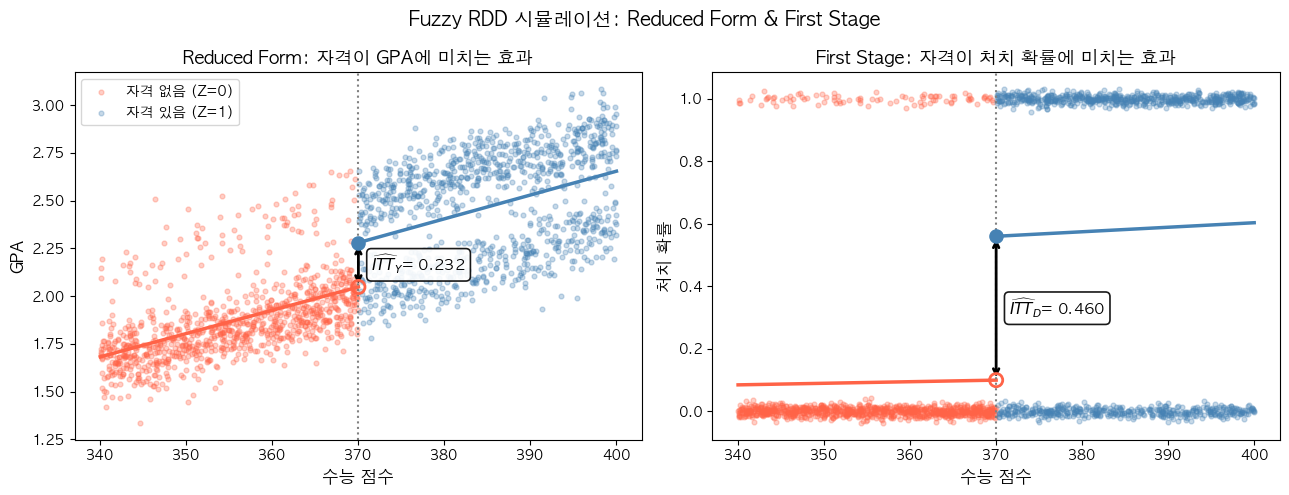

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── 왼쪽: GPA 산점도 (Reduced form) ──
ax = axes[0]
left_  = df[df['elig'] == 0]
right_ = df[df['elig'] == 1]
ax.scatter(left_['score'],  left_['gpa'],  color='tomato',    alpha=0.3, s=12, label='자격 없음 (Z=0)')
ax.scatter(right_['score'], right_['gpa'], color='steelblue', alpha=0.3, s=12, label='자격 있음 (Z=1)')

m_y_l = smf.ols('gpa ~ score_c', data=left_).fit()
m_y_r = smf.ols('gpa ~ score_c', data=right_).fit()
xs_l = np.linspace(340, cutoff, 100)
xs_r = np.linspace(cutoff, 400, 100)
ax.plot(xs_l, m_y_l.predict(pd.DataFrame({'score_c': xs_l - cutoff})), color='tomato',    lw=2.5)
ax.plot(xs_r, m_y_r.predict(pd.DataFrame({'score_c': xs_r - cutoff})), color='steelblue', lw=2.5)
y_l_gpa = m_y_l.params['Intercept']
y_r_gpa = m_y_r.params['Intercept']
ax.scatter([cutoff], [y_l_gpa], s=90, color='tomato',    zorder=6, facecolors='none', edgecolors='tomato', linewidths=2)
ax.scatter([cutoff], [y_r_gpa], s=90, color='steelblue', zorder=6)
ax.annotate('', xy=(cutoff, y_r_gpa), xytext=(cutoff, y_l_gpa),
            arrowprops=dict(arrowstyle='<->', color='black', lw=2))
ax.text(cutoff + 1.5, (y_l_gpa + y_r_gpa)/2,
        f'$\\widehat{{ITT}}_Y$= {y_r_gpa - y_l_gpa:.3f}', fontsize=11, fontweight='bold', va='center',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='black', linewidth=1.2, alpha=0.9), zorder=7)
ax.axvline(cutoff, color='gray', ls=':', lw=1.5)
ax.set_title('Reduced Form: 자격이 GPA에 미치는 효과', fontsize=13, fontweight='bold')
ax.set_xlabel('수능 점수', fontsize=12); ax.set_ylabel('GPA', fontsize=12)
ax.legend(fontsize=10)

# ── 오른쪽: 처치 확률 (First stage) ──
ax2 = axes[1]
ax2.scatter(left_['score'],  left_['treated']  + np.random.normal(0, 0.012, len(left_)),  color='tomato',    alpha=0.3, s=12)
ax2.scatter(right_['score'], right_['treated'] + np.random.normal(0, 0.012, len(right_)), color='steelblue', alpha=0.3, s=12)

m_d_l = smf.ols('treated ~ score_c', data=left_).fit()
m_d_r = smf.ols('treated ~ score_c', data=right_).fit()
ax2.plot(xs_l, m_d_l.predict(pd.DataFrame({'score_c': xs_l - cutoff})), color='tomato',    lw=2.5)
ax2.plot(xs_r, m_d_r.predict(pd.DataFrame({'score_c': xs_r - cutoff})), color='steelblue', lw=2.5)
y_l_d = m_d_l.params['Intercept']
y_r_d = m_d_r.params['Intercept']
ax2.scatter([cutoff], [y_l_d], s=90, color='tomato',    zorder=6, facecolors='none', edgecolors='tomato', linewidths=2)
ax2.scatter([cutoff], [y_r_d], s=90, color='steelblue', zorder=6)
ax2.annotate('', xy=(cutoff, y_r_d), xytext=(cutoff, y_l_d),
             arrowprops=dict(arrowstyle='<->', color='black', lw=2))
ax2.text(cutoff + 1.5, (y_l_d + y_r_d)/2,
         f'$\\widehat{{ITT}}_D$= {y_r_d - y_l_d:.3f}', fontsize=11, fontweight='bold', va='center',
         bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='black', linewidth=1.2, alpha=0.9), zorder=7)
ax2.axvline(cutoff, color='gray', ls=':', lw=1.5)
ax2.set_title('First Stage: 자격이 처치 확률에 미치는 효과', fontsize=13, fontweight='bold')
ax2.set_xlabel('수능 점수', fontsize=12); ax2.set_ylabel('처치 확률', fontsize=12)

plt.suptitle('Fuzzy RDD 시뮬레이션: Reduced Form & First Stage', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [9]:
# ── Wald 추정량으로 LATE 계산 ──
itt_y = y_r_gpa - y_l_gpa
itt_d = y_r_d   - y_l_d
late_wald = itt_y / itt_d

print("=" * 45)
print(f"  ITT_Y (Reduced form 점프) : {itt_y:.4f}")
print(f"  ITT_D (First stage 점프)  : {itt_d:.4f}")
print("-" * 45)
print(f"  Wald LATE = ITT_Y / ITT_D : {late_wald:.4f}")
print(f"  진짜 LATE                  : {true_late}")
print("=" * 45)

  ITT_Y (Reduced form 점프) : 0.2322
  ITT_D (First stage 점프)  : 0.4601
---------------------------------------------
  Wald LATE = ITT_Y / ITT_D : 0.5048
  진짜 LATE                  : 0.5


In [10]:
# ── 수동 2SLS ──
# 1단계: D ~ Z + score_c + Z*score_c
fs = smf.ols('treated ~ elig + score_c + elig:score_c', data=df).fit()
df['D_hat'] = fs.fittedvalues

# F-통계량 (elig 계수에 대한 t² ≈ F)
f_stat = (fs.params['elig'] / fs.bse['elig']) ** 2

# 2단계: Y ~ D_hat + score_c + D_hat*score_c
ss = smf.ols('gpa ~ D_hat + score_c + D_hat:score_c', data=df).fit()

print("=" * 50)
print("  [1단계 First Stage]")
print(f"  α₁ (처치 확률 점프)  : {fs.params['elig']:.4f}")
print(f"  F-통계량 (≥10이면 강한 IV): {f_stat:.1f}")
print()
print("  [2단계 Second Stage]")
print(f"  β₁ (LATE 추정치)    : {ss.params['D_hat']:.4f}")
print(f"  진짜 LATE           : {true_late}")
print("=" * 50)
print()
print("  * 표준오차는 linearmodels 등 IV 패키지로 추정해야 정확합니다.")

  [1단계 First Stage]
  α₁ (처치 확률 점프)  : 0.4601
  F-통계량 (≥10이면 강한 IV): 166.7

  [2단계 Second Stage]
  β₁ (LATE 추정치)    : 0.5047
  진짜 LATE           : 0.5

  * 표준오차는 linearmodels 등 IV 패키지로 추정해야 정확합니다.


## 참고 자료

이 노트북은 유튜브 채널 *인과추론의 데이터과학*의 RDD 강의 자료와 fuzzy regression discontinuity design의 표준 참고문헌을 바탕으로 작성되었습니다.

- **인과추론의 데이터과학**. RDD 강의 영상.  
  [https://www.youtube.com/watch?v=8SIoMJTmO3A](https://www.youtube.com/watch?v=8SIoMJTmO3A)

- **Imbens, G. W., & Lemieux, T. (2008)**. Regression discontinuity designs: A guide to practice. *Journal of Econometrics*, 142(2), 615-635.

- **Hahn, J., Todd, P., & Van der Klaauw, W. (2001)**. Identification and estimation of treatment effects with a regression-discontinuity design. *Econometrica*, 69(1), 201-209.

- **Card, D., Dobkin, C., & Maestas, N. (2008)**. The impact of nearly universal insurance coverage on health care utilization: Evidence from Medicare. *American Economic Review*, 98(5), 2242-2258.

- **Cattaneo, M. D., Idrobo, N., & Titiunik, R. (2019)**. *A Practical Introduction to Regression Discontinuity Designs*. Cambridge University Press.

